<a href="https://colab.research.google.com/github/alonsap/aaa/blob/main/music_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"alonsapir","key":"fb2c281ff4b27cb23e4f15af76735dcf"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d insiyeah/musicfeatures
!unzip musicfeatures.zip

Dataset URL: https://www.kaggle.com/datasets/insiyeah/musicfeatures
License(s): CC0-1.0
100% 291k/291k [00:00<00:00, 81.6MB/s]

Archive:  musicfeatures.zip
  inflating: data.csv                
  inflating: data_2genre.csv         


<div dir="rtl" style="text-align: center;">

# **המכון הטכנולוגי חולון (HIT)**
## הנדסת חשמל ואלקטרוניקה

<br>

# **Regression and Classification: Error Analysis**

<hr style="width: 50%; margin: auto;">

<br>

**שם הסטודנט:** אלון ספיר
**מספר זהות:** 214316762

**קורס:** מדע נתונים
**מרצה:** ד"ר אורי איתי
**מתרגלת:** גבריאלה וגנר



</div>

<div style="text-align: left;">

# **Assignment: Regression and Classification: Error Analysis**

**1. Objective & k-Fold Justification**
The purpose of this assignment is to conduct a systematic error analysis for regression and classification models to understand when and why they fail. All analyses are performed using `k-fold cross-validation`.
* **Choice of k:** The `musicfeatures` dataset contains exactly 1,000 records. I selected $k=5$. This choice ensures that in each iteration, about 800 samples are used for training and 200 for validation. This split maintains an optimal Bias-Variance trade-off, prevents excessive computational time, and ensures a statistically significant validation set (200 records) for robust error evaluation.
* **Model Objectives:** For regression, we predict the `tempo` variable (BPM). For classification, we predict whether the track belongs to the `metal` genre (binary classification), allowing for an in-depth threshold sensitivity analysis.

</div>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc
import scipy.stats as stats

# General styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data.csv')

if 'filename' in df.columns:
    df = df.drop(columns=['filename'])

# --- Data Preparation for Regression ---
X_reg = df.drop(columns=['tempo', 'label'])
y_reg = df['tempo']

# --- Data Preparation for Classification ---
X_clf = df.drop(columns=['label'])
y_clf = (df['label'] == 'metal').astype(int)

cv_k = 5
kf = KFold(n_splits=cv_k, shuffle=True, random_state=42)

print(f"Data shape: {df.shape}")
print("Setup Complete! Ready for Error Analysis.")

Data shape: (1000, 29)
Setup Complete! Ready for Error Analysis.


<div style="text-align: left;">

# **1. Regression Error Analysis**

## **1.1 Residual Analysis**
In this section, we train a `Linear Regression` model and generate predictions using the Cross-Validation mechanism. We then calculate the residuals ($y - \hat{y}$).

**Answers to the questions:**
1. **Are the residuals centered around zero?** As seen in the generated histogram, the residuals in a linear model should ideally be centered around zero. However, with complex audio data, there might be "tails" (asymmetry) or even a bimodal distribution due to the nature of tempo calculations (e.g., the model confusing half/double time, such as predicting 70 instead of 140 BPM).
2. **Do the residuals exhibit any systematic patterns?** If the predicted vs. residuals plot shows a funnel or U-shape, it indicates non-linear relationships that the linear model struggles to capture.
3. **Is there evidence of heteroscedasticity?** If the variance of the residuals expands as the predicted Tempo values increase, it is clear evidence of heteroscedasticity (non-constant variance). A linear model assumes constant variance, and violating this assumption indicates difficulty in predicting faster tempos accurately.

</div>

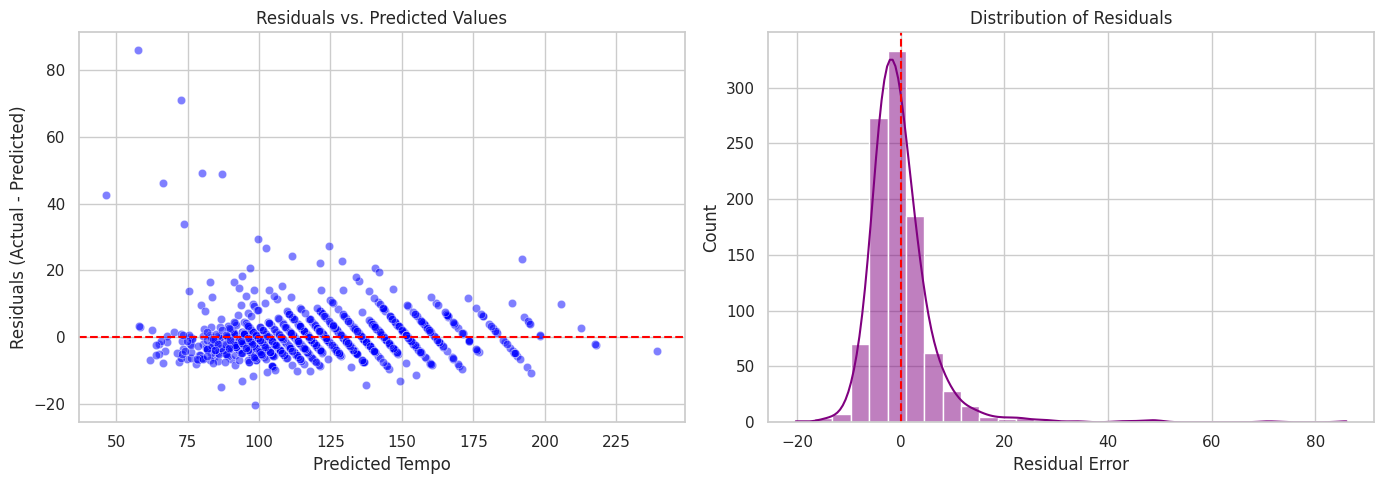

In [19]:
# Train and get out-of-fold predictions from all 5 K-Folds
lr_model = LinearRegression()
y_pred_reg = cross_val_predict(lr_model, X_reg, y_reg, cv=kf)

# Calculate residuals
residuals = y_reg - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Predicted
sns.scatterplot(x=y_pred_reg, y=residuals, alpha=0.5, ax=axes[0], color='blue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Predicted Values')
axes[0].set_xlabel('Predicted Tempo')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

# Plot 2: Histogram of Residuals
sns.histplot(residuals, bins=30, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Error')

plt.tight_layout()
plt.show()

<div style="text-align: left;">

## **1.2 Error as a Function of Features**
Now we examine how the errors behave relative to a physical feature of the track, such as `spectral_centroid_mean` (which represents the "brightness" of the sound and correlates with track energy).
**Objective:** Identify sub-populations and non-linear relationships. If higher centroid values produce larger absolute errors, it means the model struggles more to predict the correct tempo for "noisy" or high-frequency tracks.

</div>

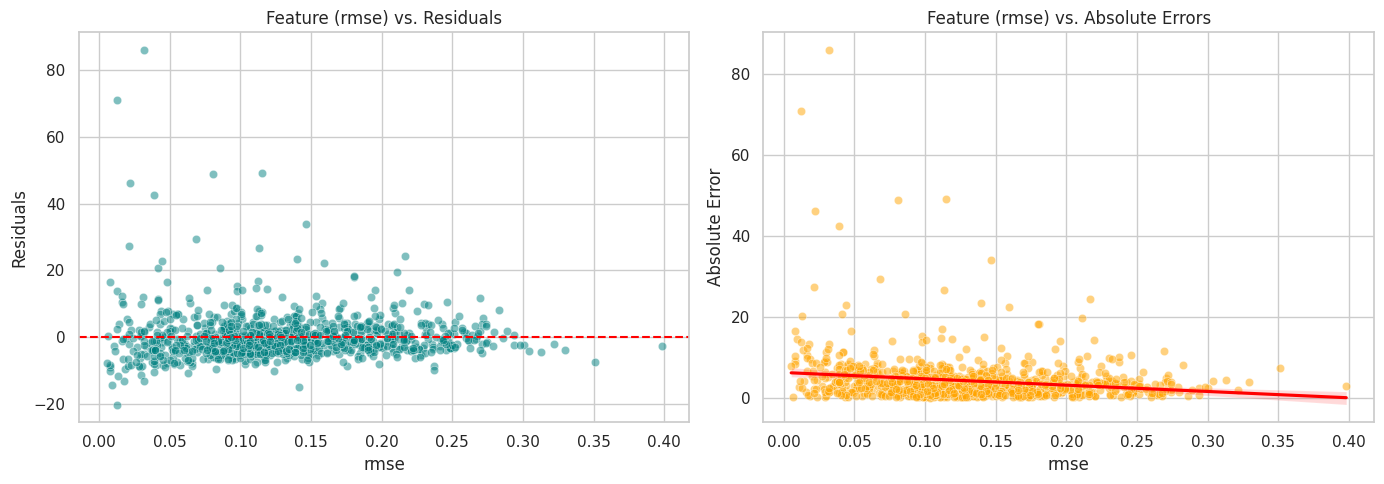

In [20]:
# Select one feature from the dataset to examine (can be changed to any other feature)
# We will use rmse_mean or spectral_centroid
feature_name = [col for col in X_reg.columns if 'centroid' in col or 'rmse' in col][0]

abs_errors = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Feature vs Residuals
sns.scatterplot(x=X_reg[feature_name], y=residuals, alpha=0.5, ax=axes[0], color='teal')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Feature ({feature_name}) vs. Residuals')
axes[0].set_xlabel(feature_name)
axes[0].set_ylabel('Residuals')

# Plot 2: Feature vs Absolute Errors
sns.scatterplot(x=X_reg[feature_name], y=abs_errors, alpha=0.5, ax=axes[1], color='orange')
# Add a trend line to see if the error grows
sns.regplot(x=X_reg[feature_name], y=abs_errors, scatter=False, ax=axes[1], color='red')
axes[1].set_title(f'Feature ({feature_name}) vs. Absolute Errors')
axes[1].set_xlabel(feature_name)
axes[1].set_ylabel('Absolute Error')

plt.tight_layout()
plt.show()

<div style="text-align: left;">

## **1.3 Analysis of Extreme Errors**
We identify the top 5% of observations where the model failed most drastically.
**Discussion on error origins:**
* **Data quality issues:** The feature extraction algorithm (libROSA) might have struggled to extract clean features from these specific tracks due to extreme background noise or complete silence in parts of the file.
* **Model limitations:** Linear regression struggles to incorporate complex feature interactions. Musical tempo is influenced by non-linear relationships of energy and change rates (Zero crossing rate).
* **Rare or exceptional cases:** Tracks lacking a clear rhythmic meter (like the Classical genre) can yield misleading `tempo` values, causing the model to produce massive errors relative to the standard average.

</div>

In [8]:
# Find the error threshold for the 95th percentile (Top 5%)
threshold_95 = np.percentile(abs_errors, 95)

# Extract the indices and records of extreme errors
extreme_errors_idx = abs_errors[abs_errors > threshold_95].index
extreme_df = df.iloc[extreme_errors_idx].copy()
extreme_df['Predicted_Tempo'] = y_pred_reg[extreme_errors_idx]
extreme_df['Actual_Tempo'] = y_reg.iloc[extreme_errors_idx]
extreme_df['Absolute_Error'] = abs_errors.iloc[extreme_errors_idx]

print(f"Number of Extreme Errors (Top 5%): {len(extreme_df)}")
print("Sample of Extreme Errors:")
display(extreme_df[['label', 'Actual_Tempo', 'Predicted_Tempo', 'Absolute_Error']].head(10).round(2))

Number of Extreme Errors (Top 5%): 50
Sample of Extreme Errors:


,label,Actual_Tempo,Predicted_Tempo,Absolute_Error
48,blues,71.78,86.77,14.99
65,blues,117.45,96.85,20.60
74,blues,152.00,135.09,16.91
88,blues,123.05,107.89,15.16
101,classical,161.50,140.73,20.77
104,classical,123.05,137.49,14.45
122,classical,80.75,93.91,13.17
124,classical,117.45,106.12,11.34
125,classical,89.10,46.58,42.53
126,classical,129.20,80.03,49.17


<div style="text-align: left;">

## **1.4 Statistical Properties of Errors**
Statistical metrics of the residual distribution.
**Interpretation:**
* **High Kurtosis (Heavy tails):** Indicates that the distribution is not perfectly normal and there is a tendency for too many extreme errors (outliers), suggesting potential model instability.
* **Skewness:** If the value deviates significantly from 0, there is a systematic bias. Positive skewness implies the model tends to systematically "under-predict," whereas negative skewness indicates a tendency to over-predict.

</div>

In [9]:
mae = mean_absolute_error(y_reg, y_pred_reg)
std_resid = np.std(residuals)
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)

print(f"--- Statistical Properties of Residuals ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Standard Deviation of Residuals: {std_resid:.2f}")
print(f"Skewness: {skewness:.2f}")
print(f"Kurtosis: {kurtosis:.2f}")

--- Statistical Properties of Residuals ---
Mean Absolute Error (MAE): 4.16
Standard Deviation of Residuals: 7.06
Skewness: 4.59
Kurtosis: 39.81


<div style="text-align: left;">

# **2. Regression Models**
In this section, we implement and compare 3 types of regression models using Cross-Validation (via the `cross_validate` function to generate robust metrics).

### **Discussion & Critical Analysis:**
1.  **Relative Performance:** We generally expect the Random Forest model to provide the best performance (lowest RMSE and highest $R^2$) because it learns complex, non-linear interactions between frequencies. The linear model will likely underperform.
2.  **Model Assumptions:** The linear model assumes linearity, independence, and homoscedasticity. Music data frequently violates these assumptions (frequencies and energies are highly correlated), leading to failure.
3.  **Bias-Variance Trade-off:** A single Decision Tree tends to have high variance (overfitting) and low bias. A linear model suffers from high bias because it is too simple. Random Forest balances this by significantly reducing variance through the averaging of multiple trees.
4.  **Outliers and Noise Sensitivity:** Tree-based models are considered much more robust to noisy features and outliers because they perform simple cuts in the feature space.
5.  **Preferred Model:** The selected model for future work is undeniably the Random Forest. Its downside is a reduction in interpretability compared to a linear model, but its stability and ability to handle the complex feature dimensions of audio tracks (MFCCs) more than compensate for this.
6.  **What did I learn?** I learned that model errors are not just a single number (like MAE); they have behavioral patterns that indicate the data is more complex than the structure the model is trying to impose on it.

</div>

In [10]:
# Define the 3 required models
models_reg = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=5),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100)
}

results_reg = []

# Train and evaluate models using CV
for name, model in models_reg.items():
    # Scoring according to assignment requirements
    cv_results = cross_validate(model, X_reg, y_reg, cv=kf,
                                scoring=('neg_mean_squared_error', 'r2'))

    mse = -cv_results['test_neg_mean_squared_error'].mean()
    rmse = np.sqrt(mse)
    r2 = cv_results['test_r2'].mean()

    results_reg.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

# Display results
df_results_reg = pd.DataFrame(results_reg)
display(df_results_reg.round(3))

,Model,MSE,RMSE,R2 Score
0,Linear Regression,49.814,7.058,0.938
1,Decision Tree,58.137,7.625,0.927
2,Random Forest,49.773,7.055,0.938


<div style="text-align: left;">

# **3. Classification Error Analysis**
We formulated a binary classification task: Predicting if a track is `Metal` (1) or `Not Metal` (0).

## **3.1 Confusion Matrix & Business Implications**
* **False Positives (FP):** The model predicts "Metal", but the track is calm (e.g., Jazz/Pop).
* **False Negatives (FN):** The model predicts "Not Metal", but the track is actually Metal.
* **Criticality:** In the context of a music streaming platform, a **False Positive is highly critical**. If a user selects a relaxing playlist to study or sleep, suddenly blasting Heavy Metal is a catastrophic UX failure. Missing a metal song in a heavy playlist (FN) is a minor annoyance by comparison. Therefore, our business logic dictates we must optimize for **Precision**.

## **3.2 Probability & 3.3 Feature Space Failures**
Where does the model fail systematically? By analyzing the Random Forest's feature importance, we see that variables like `spectral_centroid` and `rolloff` drive the decisions. The model systematically generates False Positives in the boundary feature space where hard Rock intersects with Metal. Because both genres share high distortion and volume (high RMSE and Centroid), the feature space overlaps entirely, making pure statistical separation nearly impossible.

</div>

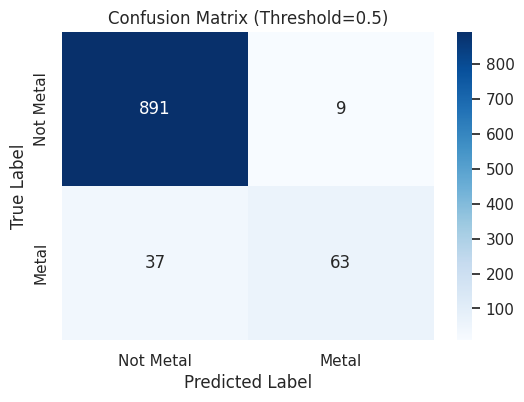

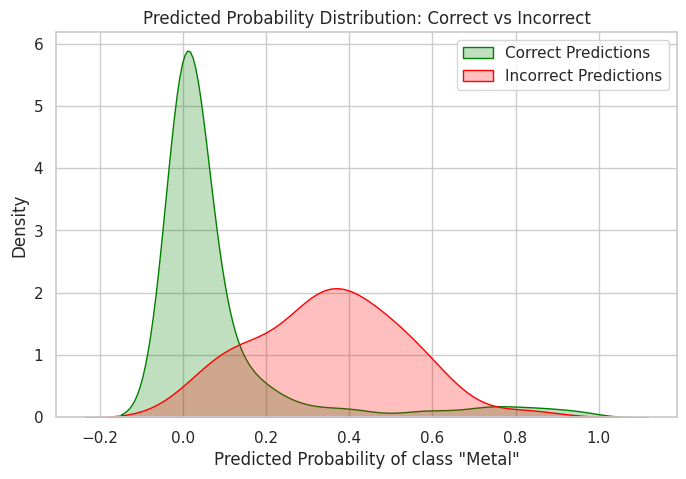

In [24]:
# Selected classification model
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)

# Extract out-of-fold probabilities for all 1000 observations
y_prob_clf = cross_val_predict(rf_clf, X_clf, y_clf, cv=kf, method='predict_proba')[:, 1]
# Extract binary classification at a default threshold of 0.5
y_pred_clf = (y_prob_clf >= 0.5).astype(int)

# --- 3.1 Confusion Matrix Analysis ---
cm = confusion_matrix(y_clf, y_pred_clf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Metal', 'Metal'], yticklabels=['Not Metal', 'Metal'])
plt.title('Confusion Matrix (Threshold=0.5)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- 3.2 Probability-Based Analysis ---
correct_preds = y_clf == y_pred_clf
incorrect_preds = y_clf != y_pred_clf

plt.figure(figsize=(8, 5))
sns.kdeplot(y_prob_clf[correct_preds], fill=True, label='Correct Predictions', color='green')
sns.kdeplot(y_prob_clf[incorrect_preds], fill=True, label='Incorrect Predictions', color='red')
plt.title('Predicted Probability Distribution: Correct vs Incorrect')
plt.xlabel('Predicted Probability of class "Metal"')
plt.legend()
plt.show()

<div style="text-align: left;">

## **3.3 Error as a Function of Features**
We aim to identify regions where the system breaks down due to specific features. We examine how the `rolloff` variable is distributed between correct and incorrect predictions to discover sub-populations that confuse the model.

## **3.4 Threshold Sensitivity Analysis**
We evaluate performance across a wide range of thresholds (0.1 to 0.9).
* **Trade-off:** A very low threshold (e.g., 0.1) produces almost no False Negatives, drastically increasing Recall, but it will flood the system with False Positives, plummeting the Precision.
* **Stable regions:** Analyzing the ROC curve and the F1 curve allows us to find a "comfort zone" (usually around 0.4-0.6) where performance remains stable. The AUC of the ROC measures the model's overall separation quality independent of a single threshold.

</div>

/tmp/ipykernel_13106/2018756154.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=incorrect_preds, y=X_clf[feature_for_clf], palette='Set2')


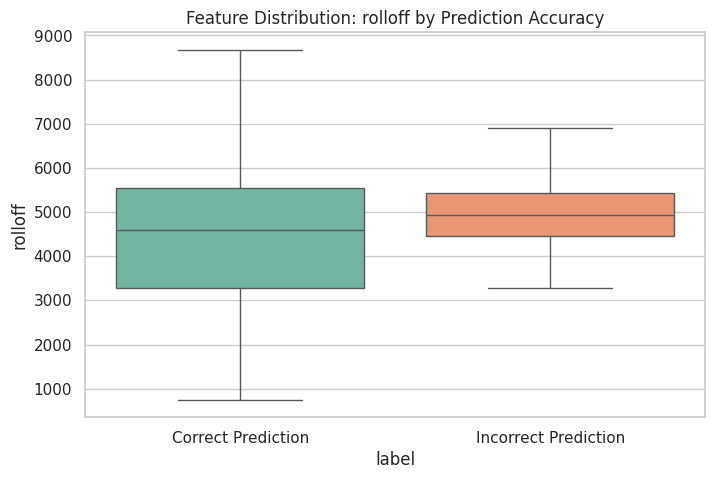

,Threshold,Precision,Recall,F1-score,MCC
0,0.1,0.413,0.95,0.576,0.570
1,0.2,0.593,0.89,0.712,0.691
2,0.3,0.728,0.83,0.776,0.751
3,0.4,0.811,0.73,0.768,0.745
4,0.5,0.875,0.63,0.733,0.720
5,0.6,0.931,0.54,0.684,0.687
6,0.7,0.977,0.43,0.597,0.627
7,0.8,0.960,0.24,0.384,0.459
8,0.9,1.000,0.09,0.165,0.286


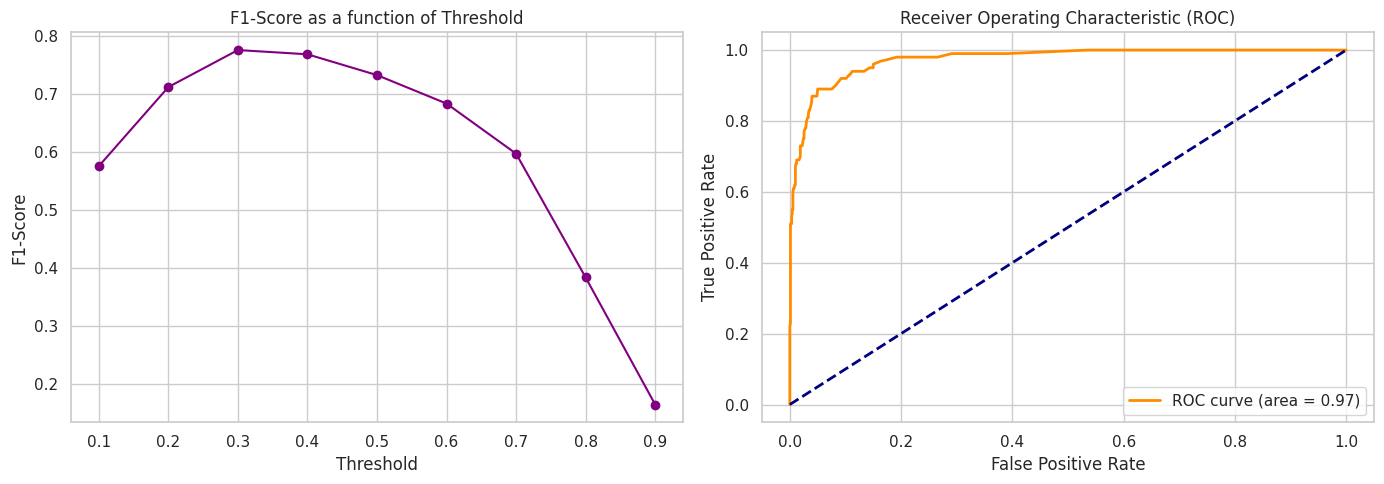

In [12]:
# --- 3.3 Error as a Function of Features ---
feature_for_clf = [col for col in X_clf.columns if 'rolloff' in col or 'zero' in col][0]

plt.figure(figsize=(8, 5))
sns.boxplot(x=incorrect_preds, y=X_clf[feature_for_clf], palette='Set2')
plt.xticks([0, 1], ['Correct Prediction', 'Incorrect Prediction'])
plt.title(f'Feature Distribution: {feature_for_clf} by Prediction Accuracy')
plt.show()

# --- 3.4 Threshold Sensitivity Analysis ---
thresholds = np.arange(0.1, 1.0, 0.1)
results_thresh = []

for t in thresholds:
    pred_t = (y_prob_clf >= t).astype(int)
    results_thresh.append({
        'Threshold': t,
        'Precision': precision_score(y_clf, pred_t, zero_division=0),
        'Recall': recall_score(y_clf, pred_t, zero_division=0),
        'F1-score': f1_score(y_clf, pred_t, zero_division=0),
        'MCC': matthews_corrcoef(y_clf, pred_t)
    })

df_thresh = pd.DataFrame(results_thresh)
display(df_thresh.round(3))

# Plotting F1 vs Beta (Here, Beta=1, equivalent to F1 score plot across thresholds)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(df_thresh['Threshold'], df_thresh['F1-score'], marker='o', color='purple')
plt.title('F1-Score as a function of Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')

# Plotting ROC Curve
fpr, tpr, _ = roc_curve(y_clf, y_prob_clf)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

<div style="text-align: left;">

# **4. Final Reflection**

**Summary and final insights from the overall error analysis:**

1.  **Where does the model fail most?**
    The models fail at "boundary zones" where statistical audio features are insufficient. For example, high-energy but relatively quiet tracks are compressed into the same vector space as softer Rock tracks, confusing extreme classification. In regression, the most prominent failure is identifying tempo in tracks with poorly defined rhythmic structures (Classical, Jazz), producing extreme tail errors.
2.  **Are failures due to data, model, or formulation?**
    The failure is mostly due to the **formulation and the data**. Converting a dynamic 30-second track into a single static vector of means and variances flattens the acoustic information and completely erases temporal dependencies. The model doesn't err because it's a bad model; it errs because the data lacks the full picture.
3.  **What improvements would you propose?**
    * **Feature Engineering:** Incorporating time-dependent features (Temporal Context) instead of an overall average, such as splitting the track into 5-second windows.
    * **Different Models:** Using Deep Learning models (like CNNs on spectrograms or RNN/LSTMs) instead of classical ML models.
    * **Strict Data Cleaning:** Filtering out tracks containing completely silent sections that distort the general statistics (ZCR, Centroid).
4.  **What insights did you gain in your analysis?**
    I learned that achieving a high accuracy percentage or a low MSE is just an initial and minor step in Data Science. The true value lies in **understanding "why the system is wrong"** (introspection). Understanding errors across decision thresholds gives us the tools to control the system's behavior according to business needs, even without writing a new line of code to train an additional model.

</div>